In [27]:
#install.packages("tidyverse")
#install.packages("DBI")
#install.packages("RSQLite")
#install.packages("sqldf")

In [28]:
# Load required R packages for SQL, database connection, and data handling
library(DBI)
library(RSQLite)
library(dplyr)
library(ggplot2)

In [29]:
# Load cleaned datasets created from Python preprocessing
deliveries <- read.csv("../outputs/deliveries_clean.csv")
orders <- read.csv("../outputs/orders_clean.csv")
customers <- read.csv("../outputs/customers_clean.csv")
drivers <- read.csv("../outputs/drivers_clean.csv")
vehicles <- read.csv("../outputs/vehicles_clean.csv")
hubs <- read.csv("../outputs/hubs_clean.csv")
complaints <- read.csv("../outputs/complaints_clean.csv")
incidents <- read.csv("../outputs/incidents_clean.csv")
app_events <- read.csv("../outputs/app_events_clean.csv")
delivery_analysis <- read.csv("../outputs/delivery_analysis_clean.csv")

In [30]:
# Create an SQLite database connection
# This allows SQL queries to be executed inside R
con <- dbConnect(SQLite(), "northstar_sql_r.db")

In [31]:
# Copy cleaned R dataframes into SQLite database tables
dbWriteTable(con, "deliveries", deliveries, overwrite = TRUE)
dbWriteTable(con, "orders", orders, overwrite = TRUE)
dbWriteTable(con, "customers", customers, overwrite = TRUE)
dbWriteTable(con, "drivers", drivers, overwrite = TRUE)
dbWriteTable(con, "vehicles", vehicles, overwrite = TRUE)
dbWriteTable(con, "hubs", hubs, overwrite = TRUE)
dbWriteTable(con, "complaints", complaints, overwrite = TRUE)
dbWriteTable(con, "incidents", incidents, overwrite = TRUE)
dbWriteTable(con, "app_events", app_events, overwrite = TRUE)
dbWriteTable(con, "delivery_analysis", delivery_analysis, overwrite = TRUE)

In [32]:
# Check all tables available in the SQLite database
dbListTables(con)

[1] "app_events"        "complaints"        "customers"        
 [4] "deliveries"        "delivery_analysis" "drivers"          
 [7] "hubs"              "incidents"         "orders"           
[10] "vehicles"

In [33]:
# SQL Query 1: Count deliveries by delivery status
query1 <- "
SELECT 
    delivery_status,
    COUNT(*) AS total_deliveries
FROM deliveries
GROUP BY delivery_status
ORDER BY total_deliveries DESC;
"

delivery_status_summary <- dbGetQuery(con, query1)
delivery_status_summary

delivery_status,total_deliveries
<chr>,<int>
ontime,540
delayed,198
failed,129


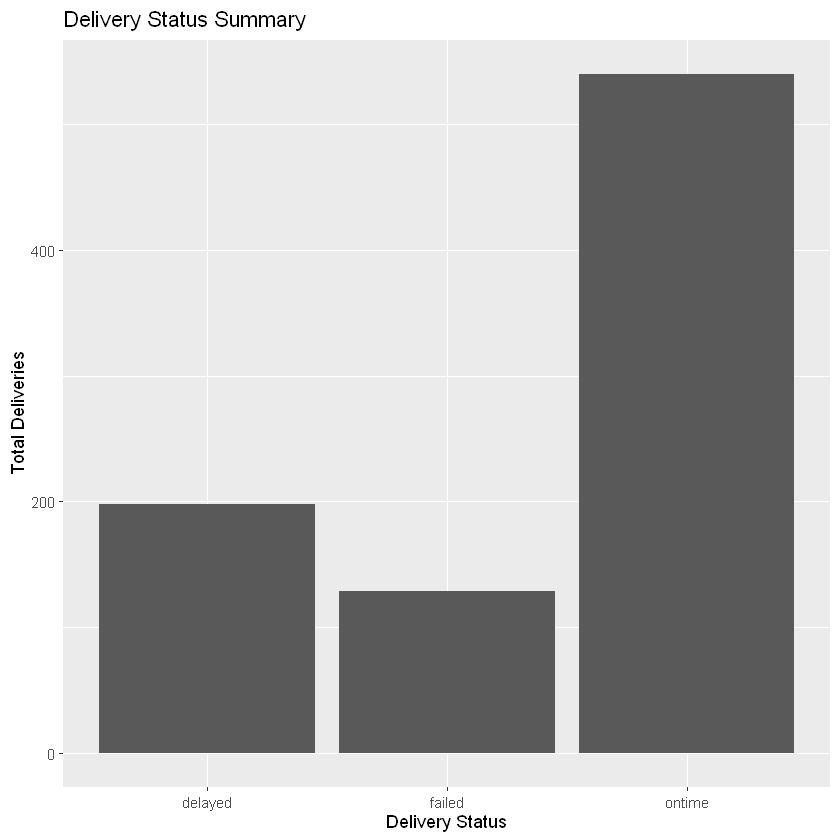

In [34]:
# Visualise delivery status summary
ggplot(delivery_status_summary, aes(x = delivery_status, y = total_deliveries)) +
  geom_col() +
  labs(
    title = "Delivery Status Summary",
    x = "Delivery Status",
    y = "Total Deliveries"
  )

In [35]:
# SQL Query 2: Calculate delay rate by hub
query2 <- "
SELECT 
    hub_name,
    COUNT(*) AS total_deliveries,
    ROUND(AVG(is_delayed) * 100, 2) AS delay_rate_percentage
FROM delivery_analysis
GROUP BY hub_name
ORDER BY delay_rate_percentage DESC;
"

delay_by_hub <- dbGetQuery(con, query2)
delay_by_hub

hub_name,total_deliveries,delay_rate_percentage
<chr>,<int>,<dbl>
Airport Hub,95,62.11
Central Core,108,54.63
West Gate,116,51.72
Midtown Relay,118,50.85
North Exchange,118,49.15
East Dock,107,45.79
South Link,97,45.36
Riverside Hub,108,42.59


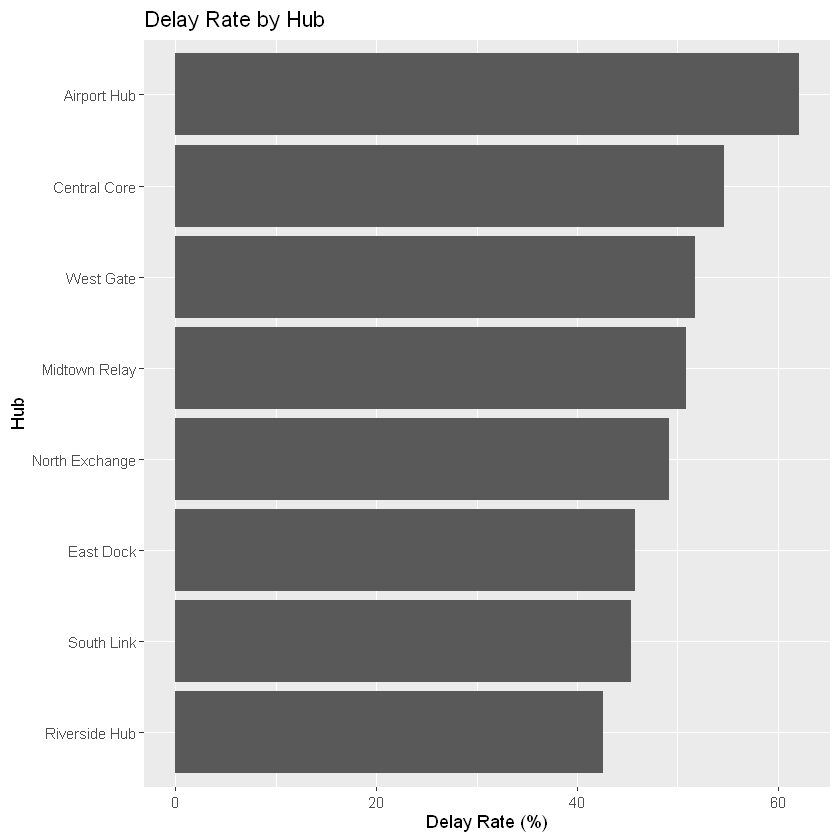

In [36]:
# Visualise delay rate by hub
ggplot(delay_by_hub, aes(x = reorder(hub_name, delay_rate_percentage), y = delay_rate_percentage)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Delay Rate by Hub",
    x = "Hub",
    y = "Delay Rate (%)"
  )

In [37]:
# SQL Query 3: Calculate failed delivery rate by service type
query3 <- "
SELECT 
    service_type,
    COUNT(*) AS total_deliveries,
    ROUND(AVG(is_failed) * 100, 2) AS failure_rate_percentage
FROM delivery_analysis
GROUP BY service_type
ORDER BY failure_rate_percentage DESC;
"

failure_by_service <- dbGetQuery(con, query3)
failure_by_service

service_type,total_deliveries,failure_rate_percentage
<chr>,<int>,<dbl>
business,114,21.93
medical,96,15.63
passenger,237,15.61
retail,212,13.21
parcel,208,11.54


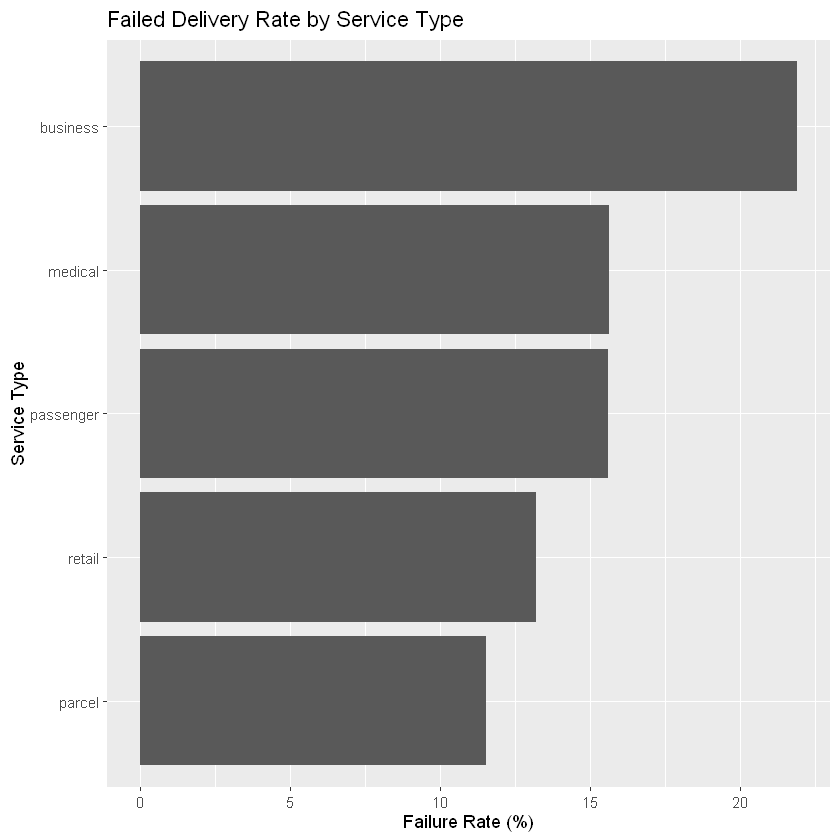

In [38]:
# Visualise failed delivery rate by service type

ggplot(failure_by_service,
       aes(x = reorder(service_type, failure_rate_percentage),
           y = failure_rate_percentage)) +

  geom_col() +

  coord_flip() +

  labs(
    title = "Failed Delivery Rate by Service Type",
    x = "Service Type",
    y = "Failure Rate (%)"
  )

In [39]:
# SQL Query 4: Analyse average delivery duration by pickup zone
query4 <- "
SELECT 
    pickup_zone,
    COUNT(*) AS total_deliveries,
    ROUND(AVG(delivery_duration_minutes), 2) AS avg_delivery_duration
FROM delivery_analysis
GROUP BY pickup_zone
ORDER BY avg_delivery_duration DESC;
"

duration_by_zone <- dbGetQuery(con, query4)
duration_by_zone

pickup_zone,total_deliveries,avg_delivery_duration
<chr>,<int>,<dbl>
ctr,59,680.02
central,99,671.54
riverside,110,645.38
east,144,625.69
west,100,609.65
south,124,590.90
north,126,587.14
airport,105,578.92


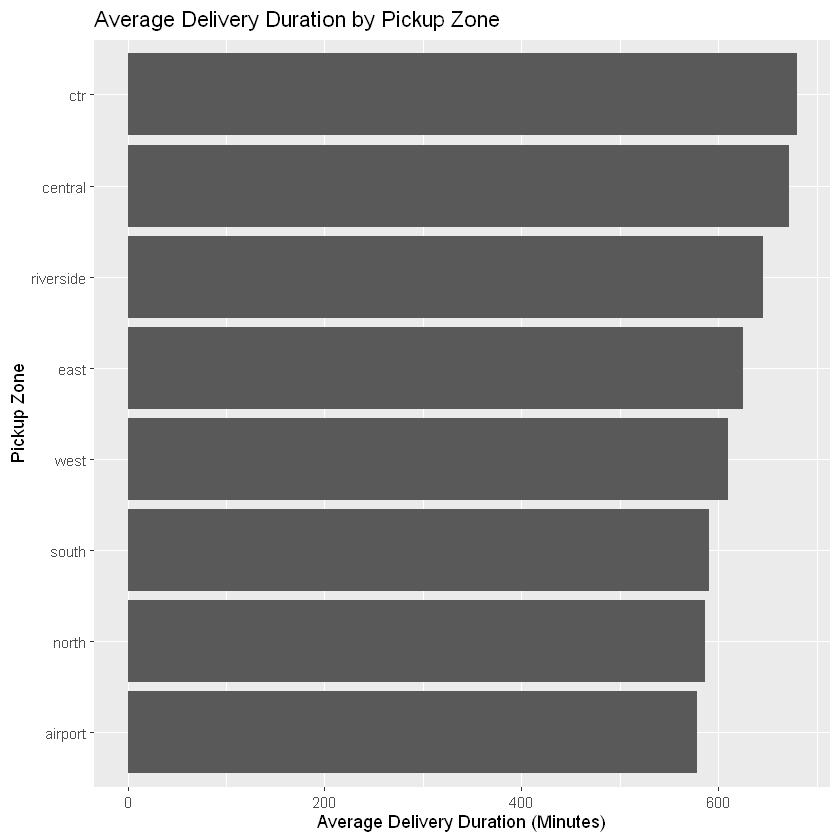

In [40]:
# Visualise average delivery duration by pickup zone

ggplot(duration_by_zone,
       aes(x = reorder(pickup_zone, avg_delivery_duration),
           y = avg_delivery_duration)) +

  geom_col() +

  coord_flip() +

  labs(
    title = "Average Delivery Duration by Pickup Zone",
    x = "Pickup Zone",
    y = "Average Delivery Duration (Minutes)"
  )

In [41]:
# SQL Query 5: Join complaints with orders and calculate complaint severity by service type
query5 <- "
SELECT 
    o.service_type,
    COUNT(c.complaint_id) AS total_complaints,
    ROUND(AVG(c.severity_score), 2) AS avg_severity_score,
    ROUND(AVG(c.compensation_amount), 2) AS avg_compensation
FROM complaints c
JOIN orders o
    ON c.order_id = o.order_id
GROUP BY o.service_type
ORDER BY avg_severity_score DESC;
"

complaints_by_service <- dbGetQuery(con, query5)
complaints_by_service

service_type,total_complaints,avg_severity_score,avg_compensation
<chr>,<int>,<dbl>,<dbl>
passenger,84,2.06,19.73
medical,37,2.05,20.00
business,39,2.05,20.79
parcel,77,2.04,19.01
retail,83,1.93,17.91


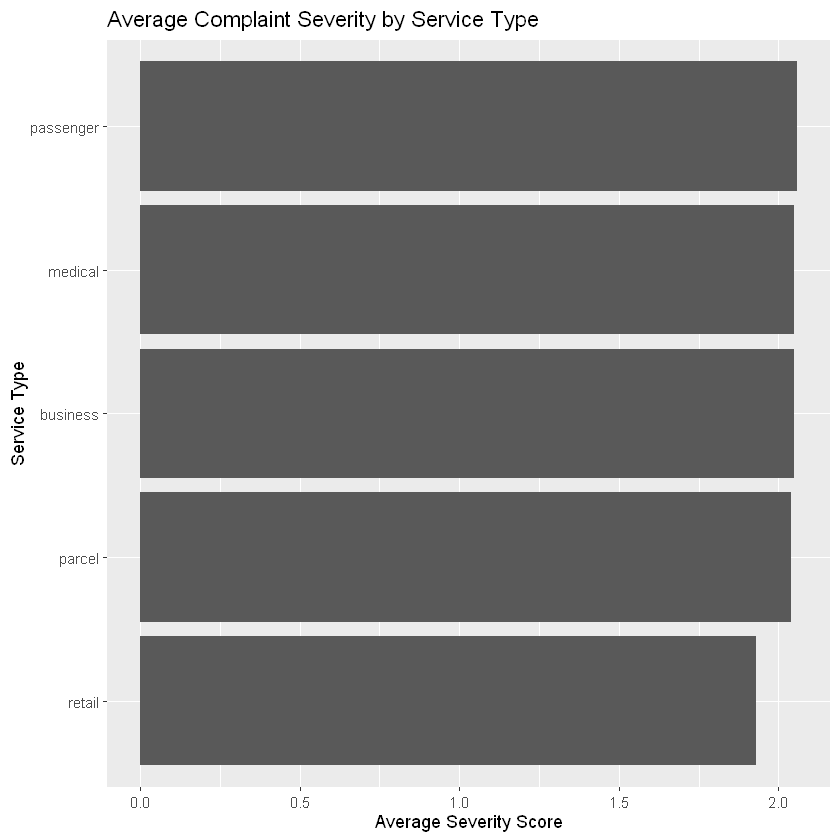

In [42]:
# Visualise complaint severity by service type

ggplot(complaints_by_service,
       aes(x = reorder(service_type, avg_severity_score),
           y = avg_severity_score)) +

  geom_col() +

  coord_flip() +

  labs(
    title = "Average Complaint Severity by Service Type",
    x = "Service Type",
    y = "Average Severity Score"
  )

In [43]:
# SQL Query 6: Compare delay rate between high-risk and non-high-risk vehicles
query6 <- "
SELECT 
    high_risk_vehicle,
    COUNT(*) AS total_deliveries,
    ROUND(AVG(is_delayed) * 100, 2) AS delay_rate_percentage,
    ROUND(AVG(is_failed) * 100, 2) AS failure_rate_percentage
FROM delivery_analysis
GROUP BY high_risk_vehicle;
"

vehicle_risk_delay <- dbGetQuery(con, query6)
vehicle_risk_delay

high_risk_vehicle,total_deliveries,delay_rate_percentage,failure_rate_percentage
<int>,<int>,<dbl>,<dbl>
0,450,48.00,8.22
1,417,52.52,22.06


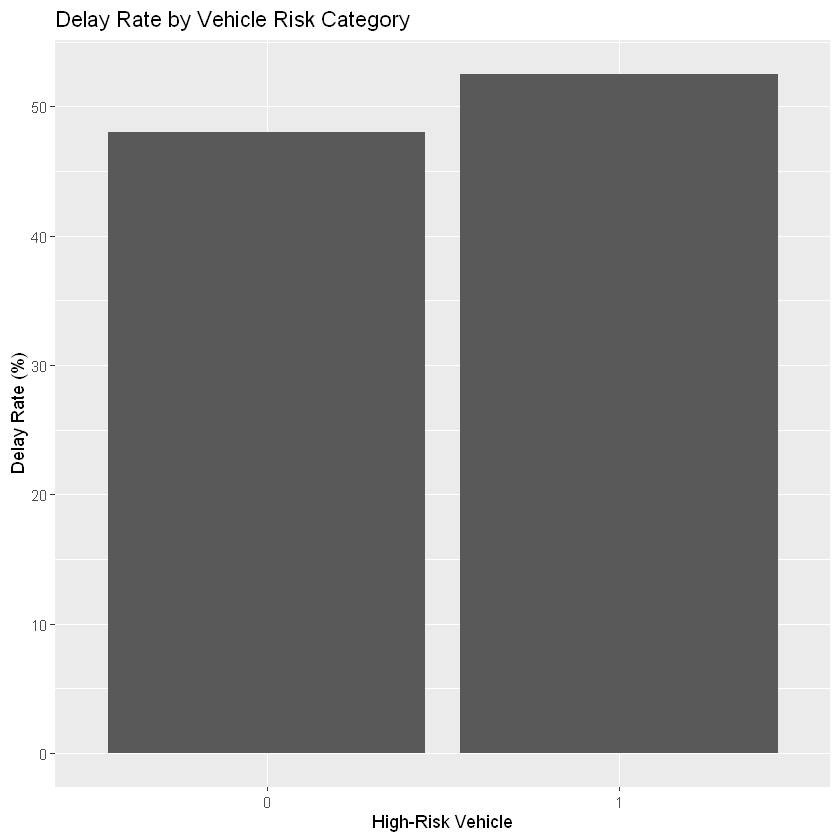

In [44]:
# Visualise operational performance by vehicle risk category

ggplot(vehicle_risk_delay,
       aes(x = as.factor(high_risk_vehicle),
           y = delay_rate_percentage)) +

  geom_col() +

  labs(
    title = "Delay Rate by Vehicle Risk Category",
    x = "High-Risk Vehicle",
    y = "Delay Rate (%)"
  )

In [45]:
# SQL Query 7: Identify drivers with highest number of incidents
# Incidents are linked through deliveries

query7 <- "
SELECT 
    d.driver_id,
    d.driver_rating,
    COUNT(i.incident_id) AS total_incidents
FROM incidents i

JOIN deliveries de
    ON i.delivery_id = de.delivery_id

JOIN drivers d
    ON de.driver_id = d.driver_id

GROUP BY d.driver_id, d.driver_rating

ORDER BY total_incidents DESC

LIMIT 10;
"

driver_incident_summary <- dbGetQuery(con, query7)

driver_incident_summary

driver_id,driver_rating,total_incidents
<chr>,<dbl>,<int>
D087,4.43,6
D004,4.75,5
D026,3.15,5
D039,4.06,5
D146,4.36,5
D002,3.94,4
D032,3.99,4
D037,4.67,4
D084,3.99,4


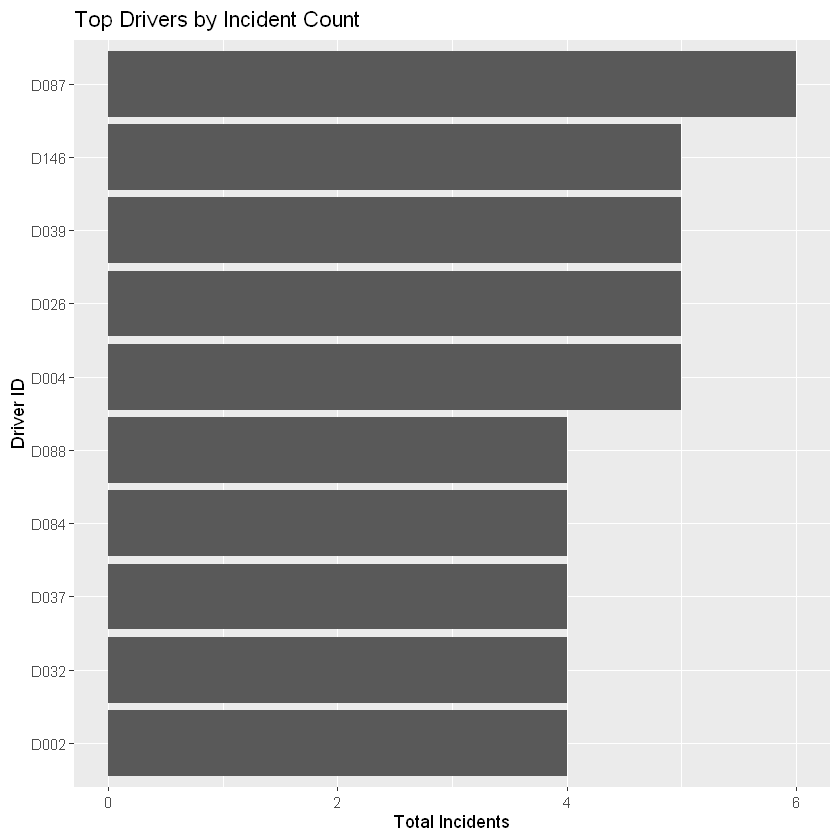

In [46]:
# Visualise drivers with highest incident counts

ggplot(driver_incident_summary,
       aes(x = reorder(driver_id, total_incidents),
           y = total_incidents)) +

  geom_col() +

  coord_flip() +

  labs(
    title = "Top Drivers by Incident Count",
    x = "Driver ID",
    y = "Total Incidents"
  )

In [47]:
# SQL Query 8: Analyse app failure rate by event type
query8 <- "
SELECT 
    event_type,
    COUNT(*) AS total_events,
    ROUND(AVG(app_event_failed) * 100, 2) AS app_failure_rate_percentage,
    ROUND(AVG(api_latency_ms), 2) AS avg_api_latency
FROM app_events
GROUP BY event_type
ORDER BY app_failure_rate_percentage DESC;
"

app_failure_summary <- dbGetQuery(con, query8)
app_failure_summary

event_type,total_events,app_failure_rate_percentage,avg_api_latency
<chr>,<int>,<dbl>,<dbl>
chat_escalated,38,50.00,478.13
payment_retry,69,27.54,472.68
track_order,138,0.00,460.71
search_route,99,0.00,456.51
eta_refresh,105,0.00,452.15
delivery_instruction_update,75,0.00,496.29
chat_opened,88,0.00,478.33
cancel_attempt,28,0.00,417.14


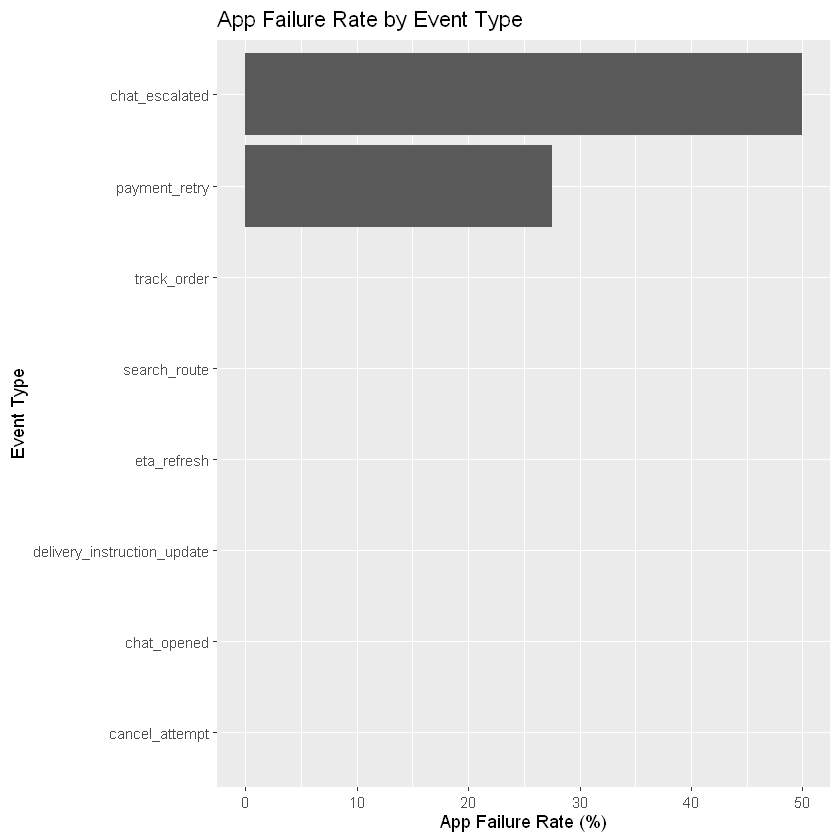

In [48]:
# Visualise app failure rate by event type

ggplot(app_failure_summary,
       aes(x = reorder(event_type, app_failure_rate_percentage),
           y = app_failure_rate_percentage)) +

  geom_col() +

  coord_flip() +

  labs(
    title = "App Failure Rate by Event Type",
    x = "Event Type",
    y = "App Failure Rate (%)"
  )

In [49]:
# Create indexes to improve query performance on commonly joined and filtered columns

dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_deliveries_order_id ON deliveries(order_id);")

dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_deliveries_driver_id ON deliveries(driver_id);")

dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_incidents_delivery_id ON incidents(delivery_id);")

dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_delivery_analysis_hub_name ON delivery_analysis(hub_name);")

dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_delivery_analysis_service_type ON delivery_analysis(service_type);")

dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_complaints_order_id ON complaints(order_id);")

dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_app_events_event_type ON app_events(event_type);")

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

In [50]:
# Use EXPLAIN QUERY PLAN to show how SQLite executes an indexed query
explain_query <- "
EXPLAIN QUERY PLAN
SELECT 
    hub_name,
    COUNT(*) AS total_deliveries,
    AVG(is_delayed) AS delay_rate
FROM delivery_analysis
GROUP BY hub_name;
"

dbGetQuery(con, explain_query)

id,parent,notused,detail
<int>,<int>,<int>,<chr>
7,0,223,SCAN delivery_analysis USING INDEX idx_delivery_analysis_hub_name


In [51]:
# Save SQL query outputs for report evidence
write.csv(delay_by_hub, "../outputs/sql_delay_by_hub.csv", row.names = FALSE)
write.csv(failure_by_service, "../outputs/sql_failure_by_service.csv", row.names = FALSE)
write.csv(duration_by_zone, "../outputs/sql_duration_by_zone.csv", row.names = FALSE)
write.csv(complaints_by_service, "../outputs/sql_complaints_by_service.csv", row.names = FALSE)
write.csv(vehicle_risk_delay, "../outputs/sql_vehicle_risk_delay.csv", row.names = FALSE)
write.csv(driver_incident_summary, "../outputs/sql_driver_incident_summary.csv", row.names = FALSE)
write.csv(app_failure_summary, "../outputs/sql_app_failure_summary.csv", row.names = FALSE)

In [52]:
# Close the database connection after completing SQL analysis
dbDisconnect(con)